In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import gpjax as gpx
import jax 
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# from gpkan.model import GPKAN
from gpkanmodel.model import GPKAN
from utils.training import *
from test_functions import *
from sklearn.model_selection import train_test_split

plt.style.use([ "science", "grid" ])
plt.rcParams.update({'axes.titlesize': 18})
plt.rcParams.update({'axes.labelsize': 15})

jax.config.update("jax_enable_x64", True)
key = jr.key(123)

/Users/aaron/Documents/masters/gpkan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/aaron/Documents/masters/gpkan/gpkanmodel/src/gpkanmodel/model.py:313: SyntaxWarning: invalid escape sequence '\s'
  f"$l$: {length_scale:.2f}, $\sigma_f^2$: {signal_variance:.2f}, $\sigma_n$: {noise_obs_stddev:.2f}"
/Users/aaron/Documents/masters/gpkan/gpkanmodel/src/gpkanmodel/model.py:313: SyntaxWarning: invalid escape sequence '\s'
  f"$l$: {length_scale:.2f}, $\sigma_f^2$: {signal_variance:.2f}, $\sigma_n$: {noise_obs_stddev:.2f}"


### Test function

In [2]:
f = lambda x, y: himmelblau(x, y) 

# samples = 40
samples = 20
x1, x2 = jnp.meshgrid(jnp.linspace(-5, 5, samples), jnp.linspace(-5 , 5, samples))
X = jnp.stack([x1.flatten(), x2.flatten()]).T
# y = jnp.log(f(X[:, 0], X[:, 1])).reshape(-1, 1)
y = jnp.sqrt(f(X[:, 0], X[:, 1]).reshape(-1, 1))
print(min(y), max(y))
function_name = "himmelblau"

[1.05485259] [29.83286778]


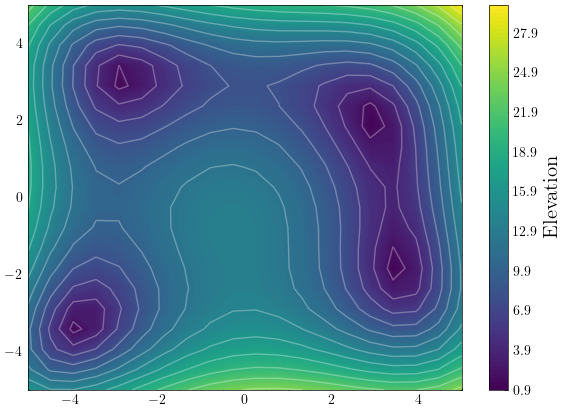

In [3]:
y_grid = y.reshape(samples, samples)
fig_data, ax_data = plt.subplots(figsize=(7, 5))
contour = ax_data.contour(x1, x2, y_grid, levels=15, colors="white", alpha=0.3)
countourf = ax_data.contourf(x1, x2, y_grid, levels=100)
cbar = fig_data.colorbar(countourf, ax=ax_data, label="Elevation")
plt.show()

## Modelling

### Initialize model

In [4]:
model_size = [2, 5, 1]
model_str = '-'.join(str(x) for x in model_size)
model = GPKAN(layers=model_size,
              n_grid_points=10, 
              grid_min=jnp.min(X), 
              grid_max=jnp.max(X),
              init_paramters=[1.75, 1.75], 
              obs_stddev=1.0
            #   init_paramters=[1.0, 1.0], 
            #   obs_stddev=0.5
            
              )

Model initialized.


### Training

In [5]:
val_grad_loss = jax.value_and_grad(
    lambda Xs_latent, ys_latent, kernel_params, X_test, y_test:
        loss_ll(y_test,
                *model.sample_statistics(Xs_latent, ys_latent, X_test, kernel_params, n_samples=10)
                ),
                argnums=(0, 1, 2)
)
val_grad_loss = jax.jit(val_grad_loss)

### Batch-wise training

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=321)

### Optimizing latent support and kernel parameters individually

In [7]:
epochs = 500 # 1000
learning_rate = 0.01
loss_history = []

batch_size = 32
patience = 100  # Number of epochs to wait for improvement
best_loss = float('inf')
patience_counter = 0

for epoch in range(epochs):
    epoch_losses = []
    current_lr = get_learning_rate(epoch, initial_lr=learning_rate)

    for i in range(0, X_train.shape[0], batch_size):
        batch_X = X_train[i:i+batch_size, :]
        batch_y = y_train[i:i+batch_size, :]

        loss, (grad_grids, grad_supports, grad_params) = val_grad_loss(
            model.latent_grids, 
            model.latent_supports,
            model.kernel_parameters,
            batch_X, batch_y
            )
        
        # Stop training if loss becomes negative
        if loss < 0 or jnp.isnan(loss):
            print(f"Stopping training at epoch {epoch} as loss became negative: {loss}")
            break 

        # grad_supports = clip_gradients(grad_supports)

        model.latent_supports = jax.tree.map(
            lambda latent_supports, grad_supports_: 
            latent_supports - grad_supports_ * current_lr,
            model.latent_supports,
            grad_supports
        )

        epoch_losses.append(loss)

    # Check for improvement
    epoch_loss = np.mean(epoch_losses)
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0 
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}, best loss: {best_loss}")
        break

    loss_history.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss: {epoch_loss:.6f}, LR: {current_lr:.6f}")
    loss_history.append(loss)

Epoch 0: Loss: 378.225213, LR: 0.010000
Epoch 10: Loss: 108.823607, LR: 0.010000
Epoch 20: Loss: 101.168481, LR: 0.010000
Epoch 30: Loss: 97.224744, LR: 0.010000
Epoch 40: Loss: 94.874849, LR: 0.010000
Epoch 50: Loss: 93.306139, LR: 0.009500
Epoch 60: Loss: 92.184866, LR: 0.009500
Epoch 70: Loss: 91.263124, LR: 0.009500
Epoch 80: Loss: 90.460087, LR: 0.009500
Epoch 90: Loss: 89.732273, LR: 0.009500
Epoch 100: Loss: 89.056249, LR: 0.009025


KeyboardInterrupt: 

In [8]:
# learning_rate = 0.01
loss_history_params = []

batch_size = 32
patience = 100  # Number of epochs to wait for improvement
best_loss = float('inf')
patience_counter = 0

for epoch in range(epochs):
    epoch_losses_params = []
    current_lr = get_learning_rate(epoch, initial_lr=learning_rate)

    for i in range(0, X_train.shape[0], batch_size):
        batch_X = X_train[i:i+batch_size, :]
        batch_y = y_train[i:i+batch_size, :]

        loss, (grad_grids, grad_supports, grad_params) = val_grad_loss(
            model.latent_grids, 
            model.latent_supports,
            model.kernel_parameters,
            batch_X, batch_y
            )
        
        # Stop training if loss becomes negative
        if loss < 0 or jnp.isnan(loss):
            print(f"Stopping training at epoch {epoch} as loss became negative: {loss}")
            break 

        grad_params = clip_gradients(grad_params)

        model.kernel_parameters = jax.tree.map(
            lambda kernel_params, grad_params_:
            kernel_params - grad_params_ * current_lr,
            model.kernel_parameters,
            grad_params 
        )

        epoch_losses_params.append(loss)

    # Check for improvement
    epoch_loss_params = np.mean(epoch_losses_params)
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0 
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch}, best loss: {best_loss}")
        break

    loss_history_params.append(epoch_loss_params)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss: {epoch_loss_params:.6f}, LR: {current_lr:.6f}")
    loss_history.append(loss)

Epoch 0: Loss: 70.047755, LR: 0.010000
Epoch 10: Loss: 61.574736, LR: 0.010000
Epoch 20: Loss: 58.774285, LR: 0.010000
Epoch 30: Loss: 56.865477, LR: 0.010000
Epoch 40: Loss: 55.289394, LR: 0.010000
Epoch 50: Loss: 53.769054, LR: 0.009500
Epoch 60: Loss: 52.320829, LR: 0.009500
Epoch 70: Loss: 50.978852, LR: 0.009500
Epoch 80: Loss: 50.073871, LR: 0.009500
Epoch 90: Loss: 49.686953, LR: 0.009500
Epoch 100: Loss: 49.516606, LR: 0.009025
Epoch 110: Loss: 49.373526, LR: 0.009025
Epoch 120: Loss: 49.231045, LR: 0.009025
Epoch 130: Loss: 49.087228, LR: 0.009025
Epoch 140: Loss: 48.941484, LR: 0.009025
Epoch 150: Loss: 48.780612, LR: 0.008574
Epoch 160: Loss: 48.638078, LR: 0.008574
Epoch 170: Loss: 48.500654, LR: 0.008574
Epoch 180: Loss: 48.367431, LR: 0.008574
Epoch 190: Loss: 48.238897, LR: 0.008574
Epoch 200: Loss: 48.096694, LR: 0.008145
Epoch 210: Loss: 47.981869, LR: 0.008145
Epoch 220: Loss: 47.870489, LR: 0.008145
Epoch 230: Loss: 47.761830, LR: 0.008145
Epoch 240: Loss: 47.656041,

### Prediction

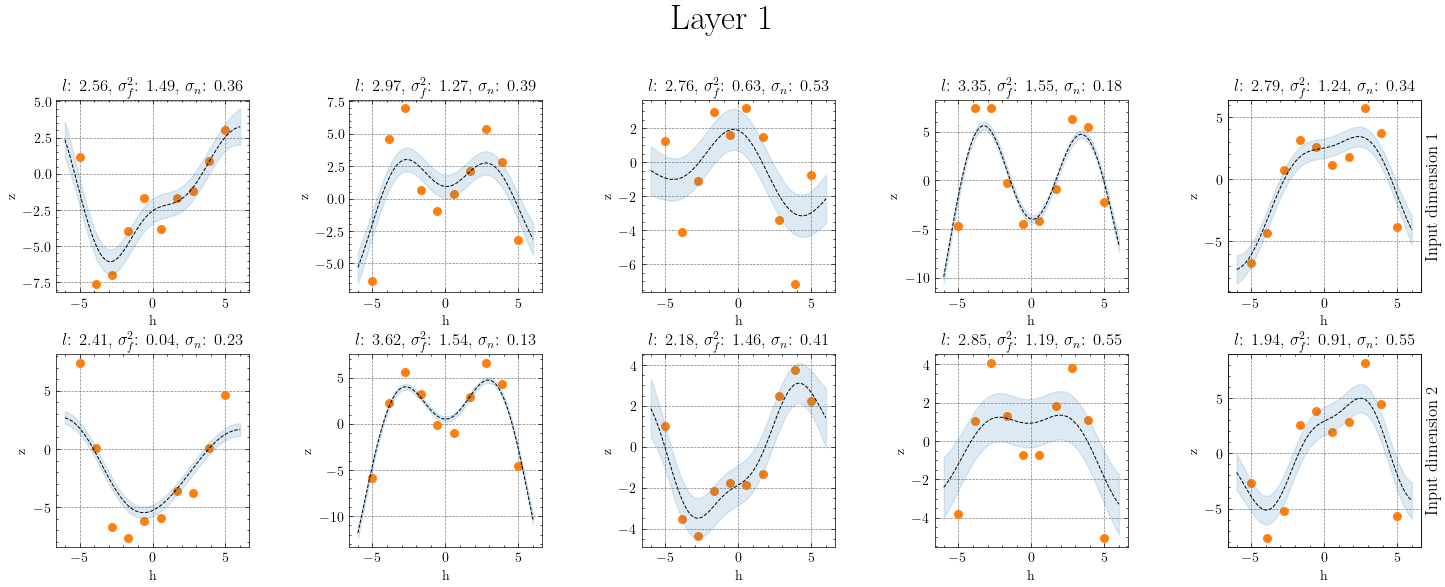

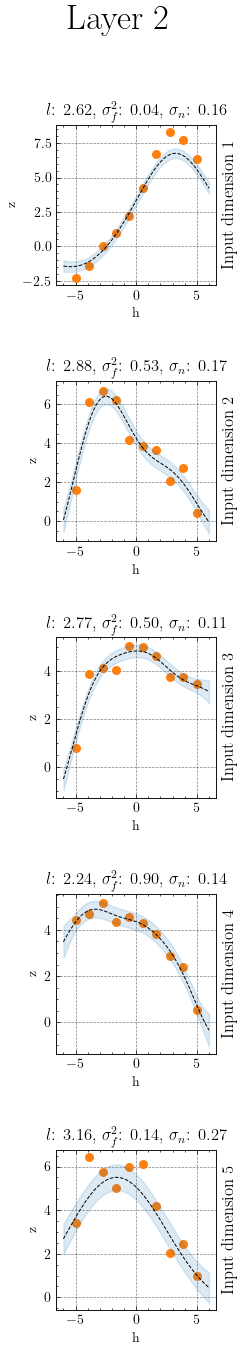

In [9]:
model.plot_neurons(
    # save_fig=True,
    save_path=f"../results/goldstein_price/figs/{function_name+" "+model_str}",
    save_fig=False,
    )

In [10]:
batch_size = 32
n = X.shape[0]
mu_batches = []
cov_blocks = []

progress_interval = max(1, int(n * 0.05) // batch_size)
for batch_idx, i in enumerate(range(0, n, batch_size)):
    X_batch = X[i:i+batch_size]
    mu_batch, cov_batch = model.sample_statistics(
        model.latent_grids, model.latent_supports, X_batch, model.kernel_parameters, 10, key=jr.key(233 + i)
    )
    mu_batches.append(mu_batch)
    cov_blocks.append(cov_batch)
    if batch_idx % progress_interval == 0 or i + batch_size >= n:
        percent = int(100 * (i + batch_size) / n)
        print(f"{percent}% done predicting...")

mu_full = jnp.concatenate(mu_batches)
cov_full = jax.scipy.linalg.block_diag(*cov_blocks)
y_stddev = jnp.sqrt(jnp.diag(cov_full))

2% done predicting...
6% done predicting...
10% done predicting...
14% done predicting...
18% done predicting...
22% done predicting...
26% done predicting...
30% done predicting...
34% done predicting...
38% done predicting...
42% done predicting...
46% done predicting...
50% done predicting...
54% done predicting...
58% done predicting...
62% done predicting...
66% done predicting...
70% done predicting...
74% done predicting...
78% done predicting...
82% done predicting...
86% done predicting...
90% done predicting...
94% done predicting...
98% done predicting...
100% done predicting...


In [11]:
# batch_size = 32 # Adjust as needed
# n = X.shape[0]
# mu_batches = []
# cov_blocks = []

# progress_interval = int(n * 0.05)
# for i in range(0, n, batch_size):
#     X_batch = X[i:i+batch_size]
#     mu_batch, cov_batch = model.sample_statistics(
#         model.latent_grids, model.latent_supports, X_batch, model.kernel_parameters, 10, key=jr.key(233 + i)
#     )
#     mu_batches.append(mu_batch)
#     cov_blocks.append(cov_batch)
#     if (i // batch_size) % (progress_interval // batch_size) == 0:
#         percent = int(100 * i / n)
#         print(f"{percent}% done predicting...")

# mu_full = jnp.concatenate(mu_batches)
# cov_full = jax.scipy.linalg.block_diag(*cov_blocks)
# y_stddev = jnp.sqrt(jnp.diag(cov_full))

In [12]:
residuals = y.flatten() - mu_full.flatten()
y_stddev = jnp.sqrt(jnp.diag(cov_full))
# y_sample = jr.multivariate_normal(jr.key(2341), mu_full, cov_full, shape=(1, )).flatten()

<>:87: SyntaxWarning: invalid escape sequence '\%'
<>:87: SyntaxWarning: invalid escape sequence '\%'
/var/folders/3z/fbv_cnz175v2v_9cqnh_3t5r0000gn/T/ipykernel_16628/2574259468.py:87: SyntaxWarning: invalid escape sequence '\%'
  cbar_row2.set_label('Relative Error (\%)')


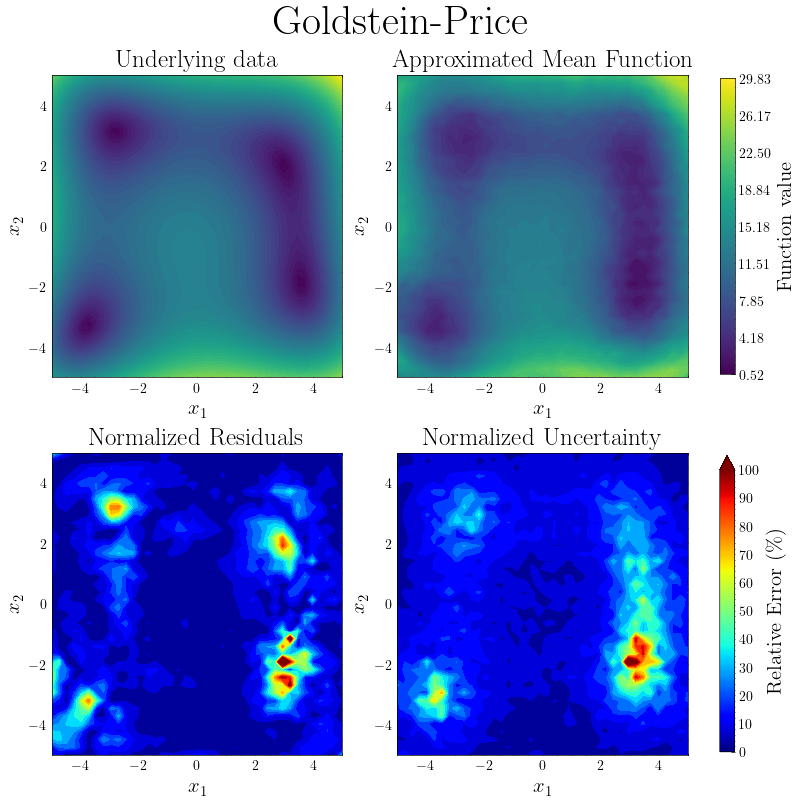

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), constrained_layout=True)
axs = axs.flatten()

# Determine the min/max values for the original function and mean
vmin = min(y.min(), mu_full.min())
vmax = max(y.max(), mu_full.max())
norm1 = plt.Normalize(vmin, vmax)

# First plot - Actual Function (unchanged)

contourf_test = axs[0].contourf(x1, x2, y.reshape(x2.shape[0], x1.shape[0]), 
                                levels=50,
                                cmap="viridis",
                                vmin=vmin,
                                vmax=vmax
                                )

axs[0].set_title("Underlying data")
axs[0].set_xlabel("$x_1$")
axs[0].set_ylabel("$x_2$")

contourf_pred = axs[1].contourf(x1, x2, mu_full.reshape(x2.shape[0], x1.shape[0]), 
                                cmap="viridis",
                                levels=50,
                                vmin=vmin,
                                vmax=vmax
                                )
                                
axs[1].set_title("Approximated Mean Function")
axs[1].set_xlabel("$x_1$")
axs[1].set_ylabel("$x_2$")

from matplotlib.cm import ScalarMappable
import numpy as np
sm1 = ScalarMappable(cmap="viridis", norm=norm1)
sm1.set_array([])  # Empty array - using the norm instead
cbar_row1 = fig.colorbar(sm1, ax=[axs[0], axs[1]], location='right', shrink=0.98)
cbar_row1.set_label("Function value")

# Create evenly spaced ticks for the first colorbar
n_ticks = 9  # Number of ticks including min and max
ticks1 = np.linspace(vmin, vmax, n_ticks)
cbar_row1.set_ticks(ticks1)
cbar_row1.set_ticklabels([f"{tick:.2f}" for tick in ticks1])  # Format to 2 decimal places)  # Optional: ensure min/max are shown

# Third plot - Normalized Residuals (as percentage of mean)
reshaped_residuals = residuals.reshape(x2.shape[0], x1.shape[0])
epsilon = 1e-10
normalized_residuals = 100 * jnp.abs(reshaped_residuals.flatten()) / (jnp.abs(mu_full.flatten()) + epsilon)
normalizeddev = 100 * (y_stddev.flatten() / (jnp.abs(mu_full.flatten()) + epsilon))

vmin_2 = min(normalized_residuals.min(), normalizeddev.min())
vmax_2 = max(normalized_residuals.max(), normalizeddev.max())
cbar_limit = 100
levels = np.linspace(vmin_2, cbar_limit, 20)

contourf_res = axs[2].contourf(x1, x2, normalized_residuals.reshape(x2.shape[0], x1.shape[0]), 
                               levels=levels, 
                               cmap="jet",
                               vmin=vmin_2,
                               vmax=cbar_limit,
                               extend="max",
                               )

axs[2].set_title("Normalized Residuals")
axs[2].set_xlabel("$x_1$")
axs[2].set_ylabel("$x_2$")

contourf_var = axs[3].contourf(x1, x2, normalizeddev.reshape(x2.shape[0], x1.shape[0]), 
                                levels=levels,
                                cmap="jet",
                                vmin=vmin_2,
                                vmax=cbar_limit,
                                extend="max",
                                )
                                
axs[3].set_title("Normalized Uncertainty")
# axs[3].set_title("Coefficient of Variation")
axs[3].set_xlabel("$x_1$")
axs[3].set_ylabel("$x_2$")

# norm2 = plt.Normalize(vmin_2, vmax_2)  # Create explicit normalization
norm2 = plt.Normalize(vmin_2, cbar_limit)  # Create explicit normalization
sm2 = ScalarMappable(cmap="jet", norm=norm2)
sm2.set_array([])  # Empty array - using the norm instead
cbar_row2 = fig.colorbar(sm2, ax=[axs[2], axs[3]], location='right', shrink=0.98, extend="max")
cbar_row2.set_label('Relative Error (\%)')

# Create evenly spaced ticks for the first colorbar
n_ticks = 9 # Number of ticks including min and max
# ticks2 = np.linspace(vmin_2, vmax_2, n_ticks)
# ticks2 = np.linspace(vmin_2, cbar_limit, n_ticks)
# ticks2 = np.linspace(0, cbar_limit, n_ticks)
ticks2 = np.arange(0, cbar_limit + 1, 10)
cbar_row2.set_ticks(ticks2)
# cbar_row2.set_ticklabels([f"{tick:.1f}" for tick in ticks2])
cbar_row2.set_ticklabels([f"{tick}" for tick in ticks2])

fig.suptitle("Goldstein-Price", fontsize=30, fontweight="bold")

# plt.subplots_adjust(top=0.88)
# plt.savefig(f"../results/goldstein_price/figs/{function_name+" "+model_str}_result.png", dpi=500, bbox_inches="tight")
plt.show()